# Backpropagation and Recurrent Networks: Implementation and Verification
**Course:** Artificial Neural Networks (20.IDI23) · **Mentor:** Prof. Branimir Todorović · **Author:** Elvir Muslić

This notebook produces every number and figure of the seminar paper *Backpropagation and Recurrent Neural Networks: Gradient-Based Training*: the backward recursion (2)–(4) of Section 2, the worked training step of Section 3 (Table 1), backpropagation through time (7)–(8) of Section 4, the Jacobian product (9) and the bound (10) of Section 5, the LSTM cell path (12) of Section 6, and the adding-problem experiment of Section 7. Run it from top to bottom, or headless with `jupyter nbconvert --to notebook --execute --inplace backprop_rnn_project.ipynb`. It saves the figures to `figures/` and the key numbers to `results.json`. Assertions stop the run if the worked step deviates from the values printed in the paper or a hand-written gradient deviates from autograd; the qualitative outcomes of the experiments are asserted with loose bounds.

## 1. Theory (brief)
A feedforward network maps $h^{(0)} = x$ through the layers $a^{(l)} = W^{(l)} h^{(l-1)} + b^{(l)}$, $h^{(l)} = \sigma(a^{(l)})$ (eq. 1). With the sensitivity $\delta^{(l)} = \partial E / \partial a^{(l)}$, the chain rule gives the **backward recursion** (2)–(4):

$$\delta^{(L)} = \nabla_{\hat y} E \odot \sigma'\big(a^{(L)}\big), \qquad
\delta^{(l)} = \big(W^{(l+1)\top} \delta^{(l+1)}\big) \odot \sigma'\big(a^{(l)}\big), \qquad
\frac{\partial E}{\partial W^{(l)}} = \delta^{(l)} h^{(l-1)\top}, \quad
\frac{\partial E}{\partial b^{(l)}} = \delta^{(l)}.$$

A recurrent network $h_t = \sigma(W_x x_t + W_h h_{t-1} + b)$ (eq. 6) uses the same weights at every step. Unfolded in time it is a deep feedforward network with tied weights. **Backpropagation through time (BPTT)** runs the recursion backward along the sequence (eq. 7) and **adds up** the per-step contributions to each shared weight (eq. 8). The sensitivity of a late state to an early one is a **product of Jacobians** (eq. 9),

$$\frac{\partial h_\tau}{\partial h_t} = \prod_{s=t+1}^{\tau} \frac{\partial h_s}{\partial h_{s-1}}, \qquad
\frac{\partial h_s}{\partial h_{s-1}} = \operatorname{diag}\big(\sigma'(a_s)\big)\, W_h ,$$

with $\tau - t$ factors, so it shrinks or grows geometrically with the distance (bound (10)). The **LSTM** (eq. 11) adds a cell state $c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t$. With the gates and the candidate $\tilde c_t$ held fixed (no derivative through $h_{t-1}$), $\partial c_t / \partial c_{t-1} = \operatorname{diag}(f_t)$ along this path (eq. 12), so when the forget gate is close to one the product no longer decays.

In [1]:
import json
import math
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

T_START = time.perf_counter()
PROJECT_DIR = Path.cwd()
assert (PROJECT_DIR / "backprop_rnn_project.ipynb").exists(), "run the notebook from its own folder"
FIG_DIR = PROJECT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

torch.set_num_threads(1)                # small matrices: one thread is fastest and keeps runs reproducible
torch.set_default_dtype(torch.float64)  # Sections 3-6 of the paper run in double precision

plt.rcParams.update({
    "figure.figsize": (4.8, 2.9),       # one column of an A4 amsart paper (text width about 5 in)
    "font.size": 9, "axes.labelsize": 9, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "pdf.fonttype": 42,                 # embed TrueType fonts in the PDF figures
})


def save_figure(fig, name):
    """Save a figure as a vector PDF in figures/ and return its path."""
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight")
    return path


def fmt(value, digits=5):
    """Format a number with a typographic minus sign."""
    return f"{value:.{digits}f}".replace("-", "−")


def sigmoid(a):
    return 1.0 / (1.0 + torch.exp(-a))


def orthogonal(n, generator):
    """Random orthogonal n x n matrix (QR of a Gaussian matrix, signs fixed)."""
    q, r = torch.linalg.qr(torch.randn(n, n, generator=generator))
    return q * torch.sign(torch.diagonal(r))


def per_step_factor(norms):
    """Least-squares slope of log(norm) against the distance k = 1, 2, ..., returned as a factor per step."""
    k = torch.arange(1, len(norms) + 1, dtype=torch.float64)
    log_norms = torch.log(torch.as_tensor(norms, dtype=torch.float64))
    slope = ((k - k.mean()) * (log_norms - log_norms.mean())).sum() / ((k - k.mean()) ** 2).sum()
    return math.exp(slope.item())


RESULTS = {
    "notebook": "backprop_rnn_project.ipynb",
    "paper": "Backpropagation and Recurrent Neural Networks: Gradient-Based Training (20.IDI23)",
    "environment": {"python": platform.python_version(), "torch": torch.__version__, "numpy": np.__version__},
    "seeds": {},
}
print(f"Python {platform.python_version()}, torch {torch.__version__}, numpy {np.__version__}")

Python 3.14.7, torch 2.14.1, numpy 2.5.3


## 2. The paper's worked step
Section 3 of the paper trains the smallest nontrivial network by hand: input $x = 1$, one hidden unit and one output unit, logistic $\sigma$ with $\sigma'(a) = \sigma(a)(1 - \sigma(a))$, loss $E = \tfrac12 (\hat y - y)^2$ with target $y = 1$, weights $W^{(1)} = W^{(2)} = 0.5$ and zero biases. The cell below repeats the forward pass (1) and the backward pass (2)–(4) and compares every printed value with the paper.

In [2]:
x, y = torch.tensor(1.0), torch.tensor(1.0)
W1, W2 = torch.tensor(0.5), torch.tensor(0.5)
b1, b2 = torch.tensor(0.0), torch.tensor(0.0)

# forward pass, eq. (1)
a1 = W1 * x + b1
h1 = sigmoid(a1)
a2 = W2 * h1 + b2
y_hat = sigmoid(a2)
E = 0.5 * (y_hat - y) ** 2

# backward pass, eqs. (2)-(4)
delta2 = (y_hat - y) * y_hat * (1 - y_hat)   # (2): dE/dy_hat times sigma'(a2)
dE_dW2 = delta2 * h1                         # (4)
delta1 = delta2 * W2 * h1 * (1 - h1)         # (3)
dE_dW1 = delta1 * x                          # (4)

PAPER_VALUES = {  # as printed in Table 1 (Section 3) of the paper
    "a1": 0.5, "h1": 0.62246, "a2": 0.31123, "y_hat": 0.57719, "E": 0.08939,
    "delta2": -0.10318, "dE_dW2": -0.06423, "delta1": -0.01212, "dE_dW1": -0.01212,
}
computed = {"a1": a1, "h1": h1, "a2": a2, "y_hat": y_hat, "E": E,
            "delta2": delta2, "dE_dW2": dE_dW2, "delta1": delta1, "dE_dW1": dE_dW1}

worked_values = {}
print(f"{'quantity':>8}  {'paper':>9}  {'computed':>12}  {'rounded':>9}")
for name, paper_value in PAPER_VALUES.items():
    value = float(computed[name])
    rounded = round(value, 5)
    correctly_rounded = math.isclose(rounded, paper_value, abs_tol=1e-12)
    assert abs(value - paper_value) <= 0.5e-5 + 1e-12 and correctly_rounded, \
        f"{name}: computed {value} rounds to {rounded}, the paper prints {paper_value}"
    worked_values[name] = {"paper": paper_value, "computed": value, "rounded_5dp": rounded,
                           "paper_is_correctly_rounded": correctly_rounded}
    print(f"{name:>8}  {fmt(paper_value):>9}  {fmt(value, 9):>12}  {fmt(rounded):>9}")

print("check: all nine values match the paper, correctly rounded to five decimals ✓")
print(f"check: ∂E/∂W2 = {fmt(float(dE_dW2))} ✓")
print(f"check: ∂E/∂W1 = {fmt(float(dE_dW1))} ✓")

quantity      paper      computed    rounded
      a1    0.50000   0.500000000    0.50000
      h1    0.62246   0.622459331    0.62246
      a2    0.31123   0.311229666    0.31123
   y_hat    0.57719   0.577185380    0.57719
       E    0.08939   0.089386101    0.08939
  delta2   −0.10318  −0.103184702   −0.10318
  dE_dW2   −0.06423  −0.064228280   −0.06423
  delta1   −0.01212  −0.012124394   −0.01212
  dE_dW1   −0.01212  −0.012124394   −0.01212
check: all nine values match the paper, correctly rounded to five decimals ✓
check: ∂E/∂W2 = −0.06423 ✓
check: ∂E/∂W1 = −0.01212 ✓


Every value in Table 1 of the paper is the double-precision result above, rounded to five decimals.

**Gradient check.** Autograd differentiates the same loss independently, and the central difference (5) uses $\epsilon = 10^{-6}$ as in the paper. Finally, one gradient-descent step with $\eta = 1$ is taken, as in Section 3, and the loss must decrease.

In [3]:
weights = torch.tensor([0.5, 0.5], requires_grad=True)
loss = 0.5 * (sigmoid(weights[1] * sigmoid(weights[0] * x)) - y) ** 2
loss.backward()
autograd_errors = {"dE_dW1": abs(weights.grad[0] - dE_dW1).item(), "dE_dW2": abs(weights.grad[1] - dE_dW2).item()}
assert max(autograd_errors.values()) <= 1e-12
print(f"check: autograd gives the same gradients, max |Δ| = {max(autograd_errors.values()):.1e} ✓")


def loss_at(w1, w2):
    return 0.5 * (sigmoid(torch.tensor(w2) * sigmoid(torch.tensor(w1) * x)) - y) ** 2


eps = 1e-6
fd_W1 = ((loss_at(0.5 + eps, 0.5) - loss_at(0.5 - eps, 0.5)) / (2 * eps)).item()
fd_W2 = ((loss_at(0.5, 0.5 + eps) - loss_at(0.5, 0.5 - eps)) / (2 * eps)).item()
fd_errors = {"dE_dW1": abs(fd_W1 - dE_dW1.item()), "dE_dW2": abs(fd_W2 - dE_dW2.item())}
assert max(fd_errors.values()) <= 1e-9
print(f"check: central difference ∂E/∂W1 ≈ {fmt(fd_W1, 7)}, |Δ| = {fd_errors['dE_dW1']:.1e} ✓")
print(f"check: central difference ∂E/∂W2 ≈ {fmt(fd_W2, 7)}, |Δ| = {fd_errors['dE_dW2']:.1e} ✓")

# one gradient-descent step W <- W - eta dE/dW with eta = 1, as taken in Section 3 of the paper
ETA = 1.0
W1_new, W2_new = W1 - ETA * dE_dW1, W2 - ETA * dE_dW2
y_hat_new = sigmoid(W2_new * sigmoid(W1_new * x))
E_new = 0.5 * (y_hat_new - y) ** 2
STEP_PAPER = {"W1": 0.512124, "W2": 0.564228, "y_hat": 0.587300, "E": 0.085161}  # as printed in Section 3
step_computed = {"W1": float(W1_new), "W2": float(W2_new), "y_hat": float(y_hat_new), "E": float(E_new)}
for name, paper_value in STEP_PAPER.items():
    assert round(step_computed[name], 6) == paper_value, f"step: {name} = {step_computed[name]}, the paper prints {paper_value}"
assert E_new < E
print(f"check: one step with η = 1 gives W1 = {step_computed['W1']:.6f}, W2 = {step_computed['W2']:.6f}, "
      f"ŷ = {step_computed['y_hat']:.6f}; E falls from {float(E):.6f} to {step_computed['E']:.6f} ✓")

RESULTS["worked_step"] = {
    "setup": "x=1, y=1, W1=W2=0.5, zero biases, logistic sigma, E=0.5*(y_hat-y)^2",
    "values": worked_values,
    "autograd_abs_error": autograd_errors,
    "finite_difference": {"epsilon": eps, "dE_dW1": fd_W1, "dE_dW2": fd_W2, "abs_error": fd_errors},
    "gradient_step": {"eta": ETA, "E_before": float(E), "after": step_computed},
}

check: autograd gives the same gradients, max |Δ| = 2.8e-17 ✓
check: central difference ∂E/∂W1 ≈ −0.0121244, |Δ| = 2.2e-12 ✓
check: central difference ∂E/∂W2 ≈ −0.0642283, |Δ| = 2.9e-11 ✓
check: one step with η = 1 gives W1 = 0.512124, W2 = 0.564228, ŷ = 0.587300; E falls from 0.089386 to 0.085161 ✓


**Any depth.** The same recursion works for a network of any depth. Below, (2)–(4) are implemented for an $L$-layer network and compared with autograd on a random network with layer sizes 4-8-8-3 (tanh, tanh, logistic) and the same squared-error loss.

In [4]:
ACTIVATIONS = {  # function and its derivative written through the output h = sigma(a)
    "tanh": (torch.tanh, lambda h: 1 - h ** 2),
    "logistic": (sigmoid, lambda h: h * (1 - h)),
}


def mlp_forward(params, activations, x):
    """Forward pass (1); returns the outputs h^(0), ..., h^(L)."""
    outputs = [x]
    for (W, b), name in zip(params, activations):
        outputs.append(ACTIVATIONS[name][0](W @ outputs[-1] + b))
    return outputs


def mlp_backward(params, activations, outputs, y):
    """Backward recursion (2)-(4) for E = 0.5 * ||y_hat - y||^2; returns [(dE/dW, dE/db) per layer]."""
    grads = [None] * len(params)
    delta = (outputs[-1] - y) * ACTIVATIONS[activations[-1]][1](outputs[-1])                 # (2)
    for l in reversed(range(len(params))):
        grads[l] = (torch.outer(delta, outputs[l]), delta.clone())                         # (4)
        if l > 0:
            delta = (params[l][0].T @ delta) * ACTIVATIONS[activations[l - 1]][1](outputs[l])  # (3)
    return grads


SEED_MLP = 0
RESULTS["seeds"]["mlp_check"] = SEED_MLP
gen = torch.Generator().manual_seed(SEED_MLP)
sizes, activations = [4, 8, 8, 3], ["tanh", "tanh", "logistic"]
params = [(torch.randn(m, n, generator=gen) / math.sqrt(n), 0.1 * torch.randn(m, generator=gen))
          for n, m in zip(sizes[:-1], sizes[1:])]
x_in, y_target = torch.randn(4, generator=gen), torch.rand(3, generator=gen)

manual = mlp_backward(params, activations, mlp_forward(params, activations, x_in), y_target)

leaves = [(W.clone().requires_grad_(), b.clone().requires_grad_()) for W, b in params]
(0.5 * ((mlp_forward(leaves, activations, x_in)[-1] - y_target) ** 2).sum()).backward()
mlp_error = max(((g - p.grad).abs().max() / p.grad.abs().max()).item()
                for g_pair, p_pair in zip(manual, leaves) for g, p in zip(g_pair, p_pair))
assert mlp_error <= 1e-12
print(f"check: recursion (2)-(4) = autograd on a 4-8-8-3 network, max relative error {mlp_error:.1e} ✓")
RESULTS["mlp_check"] = {"sizes": sizes, "activations": activations, "loss": "0.5*||y_hat-y||^2",
                        "max_relative_error": mlp_error}

check: recursion (2)-(4) = autograd on a 4-8-8-3 network, max relative error 4.1e-16 ✓


## 3. BPTT for an RNN
We take $h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$, which is (6) with $\sigma = \tanh$, start from $h_0 = 0$, feed $\tau = 20$ random inputs, and put the loss on a linear readout of the **last** state, $E = \tfrac12 \lVert V h_\tau + c - y \rVert^2$, as in Section 4 of the paper. BPTT (7) walks back from $t = \tau$ to $t = 1$:

$$g_\tau = V^\top(\hat y - y), \qquad \delta_t = \frac{\partial E}{\partial a_t} = g_t \odot (1 - h_t^2), \qquad g_{t-1} = W_h^\top \delta_t ,$$

and every step adds its own term $\delta_t h_{t-1}^\top$ to $\partial E / \partial W_h$ (and $\delta_t x_t^\top$ to $\partial E/\partial W_x$, $\delta_t$ to $\partial E/\partial b$), which is the sum (8).

check: hand-written BPTT = autograd for Wx, Wh, b, V, c, max relative error 0.0e+00 ✓
check: the 20 per-step terms add up to autograd's dE/dWh, relative error 0.0e+00 ✓
‖δ_t h_{t-1}^T‖ by step t: t=2: 9.3e-05  t=5: 3.2e-04  t=10: 2.0e-02  t=15: 2.2e-01  t=20: 1.9e+00


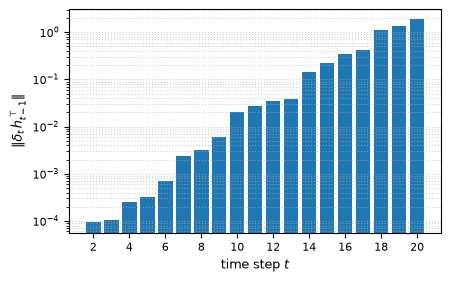

In [5]:
def rnn_forward(Wx, Wh, b, V, c, xs):
    """Run h_t = tanh(Wx x_t + Wh h_{t-1} + b) from h_0 = 0; return the states and the readout V h_tau + c."""
    states = [torch.zeros(Wh.shape[0])]
    for x_t in xs:
        states.append(torch.tanh(Wx @ x_t + Wh @ states[-1] + b))
    return states, V @ states[-1] + c


def rnn_bptt(Wx, Wh, b, V, c, xs, states, y_hat, y):
    """Hand-written BPTT for E = 0.5 * ||y_hat - y||^2; also returns each step's term in dE/dWh."""
    error = y_hat - y
    grads = {"Wx": torch.zeros_like(Wx), "Wh": torch.zeros_like(Wh), "b": torch.zeros_like(b),
             "V": torch.outer(error, states[-1]), "c": error.clone()}
    g = V.T @ error                                  # dE/dh_tau
    step_terms = {}
    for t in range(len(xs), 0, -1):
        delta = g * (1 - states[t] ** 2)             # dE/da_t
        step_terms[t] = torch.outer(delta, states[t - 1])
        grads["Wh"] += step_terms[t]
        grads["Wx"] += torch.outer(delta, xs[t - 1])
        grads["b"] += delta
        g = Wh.T @ delta                             # dE/dh_{t-1}
    return grads, step_terms


SEED_BPTT = 1
RESULTS["seeds"]["bptt_check"] = SEED_BPTT
gen = torch.Generator().manual_seed(SEED_BPTT)
n_in, n_hidden, n_out, tau = 3, 16, 2, 20
rnn_params = {
    "Wx": torch.randn(n_hidden, n_in, generator=gen) / math.sqrt(n_in),
    "Wh": 0.9 * orthogonal(n_hidden, gen),
    "b": 0.1 * torch.randn(n_hidden, generator=gen),
    "V": torch.randn(n_out, n_hidden, generator=gen) / math.sqrt(n_hidden),
    "c": 0.1 * torch.randn(n_out, generator=gen),
}
xs = torch.randn(tau, n_in, generator=gen)
y_seq = torch.randn(n_out, generator=gen)

states, y_hat_seq = rnn_forward(*rnn_params.values(), xs)
bptt_grads, step_terms = rnn_bptt(*rnn_params.values(), xs, states, y_hat_seq, y_seq)

leaves = {name: p.clone().requires_grad_() for name, p in rnn_params.items()}
_, y_auto = rnn_forward(*leaves.values(), xs)
(0.5 * ((y_auto - y_seq) ** 2).sum()).backward()
bptt_error = max(((bptt_grads[k] - leaves[k].grad).abs().max() / leaves[k].grad.abs().max()).item() for k in leaves)
assert bptt_error <= 1e-12
print(f"check: hand-written BPTT = autograd for Wx, Wh, b, V, c, max relative error {bptt_error:.1e} ✓")

term_sum = sum(step_terms.values())
sum_error = ((term_sum - leaves["Wh"].grad).norm() / leaves["Wh"].grad.norm()).item()
assert sum_error <= 1e-12
print(f"check: the {tau} per-step terms add up to autograd's dE/dWh, relative error {sum_error:.1e} ✓")

term_norms = {t: step_terms[t].norm().item() for t in range(1, tau + 1)}
assert term_norms[1] == 0.0  # h_0 = 0, so the first step adds nothing to dE/dWh
print("‖δ_t h_{t-1}^T‖ by step t:", "  ".join(f"t={t}: {v:.1e}" for t, v in term_norms.items() if t in (2, 5, 10, 15, 20)))

fig, ax = plt.subplots()
steps = list(range(2, tau + 1))
ax.bar(steps, [term_norms[t] for t in steps], color="tab:blue")
ax.set_yscale("log")
ax.set_xlabel("time step $t$")
ax.set_ylabel(r"$\|\delta_t\, h_{t-1}^\top\|$")
ax.set_xticks(steps[::2])
ax.grid(True, axis="y", which="both", linestyle=":", alpha=0.6)
save_figure(fig, "bptt_contributions.pdf")
plt.show()

RESULTS["bptt_check"] = {
    "tau": tau, "hidden": n_hidden, "inputs": n_in, "outputs": n_out, "spectral_norm_Wh": 0.9,
    "loss": "0.5*||V h_tau + c - y||^2 (last state only)",
    "max_relative_error": bptt_error, "sum_of_step_terms_relative_error": sum_error,
    "step_term_norms": term_norms,
}

The bars are the per-step terms of $\partial E/\partial W_h$. Their sum is exactly the BPTT gradient, and the early steps contribute several orders of magnitude less than the late ones: the error signal reaching step $t$ has passed through $\tau - t$ Jacobians. The first step is missing because $h_0 = 0$ makes its term zero.

## 4. Vanishing and exploding gradients
This is the measurement of Section 5 of the paper (product (9), bound (10)). We measure $\lVert \partial h_\tau / \partial h_{\tau-k} \rVert$ (spectral norm) against the distance $k$ for a 32-unit tanh RNN run for $\tau = 60$ steps. The recurrent matrix is $W_h = \rho Q$ with $Q$ orthogonal, so every singular value of $W_h$ equals $\rho$. With tiny inputs the states stay near zero, $1 - h_s^2 \approx 1$, and the product behaves like $\rho^k$. With large inputs many units **saturate**, $1 - h_s^2 \to 0$ for them, and the gradient vanishes even when $\rho > 1$. Each product is built from the per-step Jacobians $\operatorname{diag}(1 - h_s^2) W_h$ and checked against autograd's Jacobian. The bound (10), which uses only the largest entry of each factor $\operatorname{diag}(1 - h_s^2)$ together with $\lVert W_h \rVert_2 = \rho$, is evaluated along each trajectory and must hold for every $k$.

check: ρ=0.9, small inputs  product = autograd (rel. error 1.8e-15); factor per step 0.9000, ‖J_60‖ = 1.8e-03 ≤ bound (10) = 0.0018, max |h| = 0.00073 ✓
check: ρ=1.1, small inputs  product = autograd (rel. error 1.6e-15); factor per step 1.0999, ‖J_60‖ = 3.0e+02 ≤ bound (10) = 304, max |h| = 0.13 ✓
check: ρ=1.1, saturated     product = autograd (rel. error 4.7e-15); factor per step 0.4750, ‖J_60‖ = 7.8e-19 ≤ bound (10) = 100, max |h| = 1 ✓
check: decay for ρ = 0.9, growth for ρ = 1.1, decay again when tanh saturates ✓


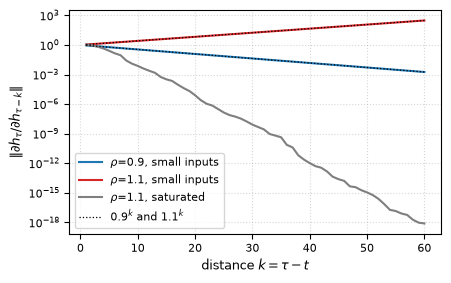

In [6]:
SEED_JACOBIAN = 2
RESULTS["seeds"]["jacobian"] = SEED_JACOBIAN
HORIZON, N_UNITS, N_INPUTS = 60, 32, 4


def rnn_jacobian_norms(rho, input_scale, horizon=HORIZON, n=N_UNITS, seed=SEED_JACOBIAN):
    """Norms of d h_K / d h_{K-k}, k = 1..K, from the product of per-step Jacobians, plus an autograd check."""
    gen = torch.Generator().manual_seed(seed)
    Wh = rho * orthogonal(n, gen)
    Wx = torch.randn(n, N_INPUTS, generator=gen) / 2.0
    xs = input_scale * torch.randn(horizon, N_INPUTS, generator=gen)
    states = [torch.zeros(n)]
    for t in range(horizon):
        states.append(torch.tanh(Wx @ xs[t] + Wh @ states[-1]))

    products, J = [], torch.eye(n)
    for k in range(1, horizon + 1):
        J = J @ (torch.diag(1 - states[horizon - k + 1] ** 2) @ Wh)   # one more factor, further back in time
        products.append(J.clone())

    worst = 0.0
    for k in (1, 10, 30, horizon):
        start = horizon - k

        def run_from(h, start=start):
            for t in range(start, horizon):
                h = torch.tanh(Wx @ xs[t] + Wh @ h)
            return h

        J_auto = torch.autograd.functional.jacobian(run_from, states[start])
        worst = max(worst, ((J_auto - products[k - 1]).abs().max() / J_auto.abs().max()).item())
    norms = [torch.linalg.matrix_norm(P, ord=2).item() for P in products]
    bounds, bound = [], 1.0                    # bound (10): product of ||diag(1 - h_s^2)||_2 ||W_h||_2
    for k in range(1, horizon + 1):
        bound *= float((1 - states[horizon - k + 1] ** 2).max()) * rho
        bounds.append(bound)
    return norms, worst, max(s.abs().max().item() for s in states), bounds


RNN_CASES = {
    "rho=0.9, small inputs": (0.9, 1e-4),
    "rho=1.1, small inputs": (1.1, 1e-4),
    "rho=1.1, saturated": (1.1, 3.0),
}
rnn_jacobian = {}
for label, (rho, scale) in RNN_CASES.items():
    norms, worst, max_h, bounds = rnn_jacobian_norms(rho, scale)
    assert worst <= 1e-12, f"{label}: product differs from autograd ({worst:.1e})"
    assert all(n <= b * (1 + 1e-12) for n, b in zip(norms, bounds)), f"{label}: bound (10) violated"
    factor = per_step_factor(norms)
    rnn_jacobian[label] = {"rho": rho, "input_scale": scale, "factor_per_step": factor,
                           "norm_k1": norms[0], "norm_k30": norms[29], "norm_k60": norms[-1],
                           "max_abs_state": max_h, "autograd_max_relative_error": worst, "norms": norms,
                           "bound_k60": bounds[-1]}
    print(f"check: {label.replace('rho', 'ρ'):20s} product = autograd (rel. error {worst:.1e}); factor per step {factor:.4f}, "
          f"‖J_60‖ = {norms[-1]:.1e} ≤ bound (10) = {bounds[-1]:.3g}, max |h| = {max_h:.2g} ✓")

assert 0.8 < rnn_jacobian["rho=0.9, small inputs"]["factor_per_step"] < 0.95       # vanishing
assert rnn_jacobian["rho=1.1, small inputs"]["factor_per_step"] > 1.05              # exploding
assert rnn_jacobian["rho=1.1, saturated"]["factor_per_step"] < 0.9                  # saturation turns growth into decay
print("check: decay for ρ = 0.9, growth for ρ = 1.1, decay again when tanh saturates ✓")

fig, ax = plt.subplots()
k_axis = np.arange(1, HORIZON + 1)
for (label, row), color in zip(rnn_jacobian.items(), ("tab:blue", "tab:red", "tab:gray")):
    ax.semilogy(k_axis, row["norms"], color=color, label=label.replace("rho", r"$\rho$"))
ax.semilogy(k_axis, 0.9 ** k_axis, "k:", linewidth=0.9, label=r"$0.9^k$ and $1.1^k$")
ax.semilogy(k_axis, 1.1 ** k_axis, "k:", linewidth=0.9)
ax.set_xlabel(r"distance $k = \tau - t$")
ax.set_ylabel(r"$\|\partial h_\tau / \partial h_{\tau-k}\|$")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="lower left")
save_figure(fig, "jacobian_decay.pdf")
plt.show()

**The LSTM cell path** (Section 6 of the paper). Along the cell state, with the gates and the candidate $\tilde c_t$ held fixed, $c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t$ (eq. 11) gives $\partial c_t / \partial c_{t-1} = \operatorname{diag}(f_t)$, so $\partial c_\tau / \partial c_{\tau-k} = \prod_{s} \operatorname{diag}(f_s)$ over the last $k$ steps (eq. 12). Below, an LSTM cell with 32 units and small random weights runs for 60 steps with forget-gate bias $b_f = 3$ ($f \approx 0.95$) and $b_f = 8$ ($f \approx 0.9997$). Autograd is applied with $h_{t-1}$ detached in all four pre-activations (the gates and the candidate $\tilde c_t$), which keeps exactly this direct path, and it must agree with the explicit product.

**The full derivative.** The gates and $\tilde c_t$ also depend on $h_{t-1} = o_{t-1} \odot \tanh(c_{t-1})$, so $c_{t-1}$ reaches $c_t$ through $h$ as well. For the same cell and the same trajectory, autograd without the detach gives the full Jacobian $\partial c_\tau / \partial c_{\tau-k}$, all paths included.

check: b_f = 3: autograd = ∏ diag(f_t) (rel. error 1.2e-15); mean f = 0.9525, factor per step 0.9529, ‖∂c_60/∂c_0‖ = 0.056 ✓
       full derivative (paths through h into c~ and the gates kept): factor per step 0.9805, ‖∂c_60/∂c_0‖ = 0.299
check: b_f = 8: autograd = ∏ diag(f_t) (rel. error 9.1e-16); mean f = 0.9997, factor per step 0.9997, ‖∂c_60/∂c_0‖ = 0.980 ✓
       full derivative (paths through h into c~ and the gates kept): factor per step 1.0273, ‖∂c_60/∂c_0‖ = 4.886
check: after 60 steps the cell path keeps 0.980 for b_f = 8 and 0.056 for b_f = 3 ✓


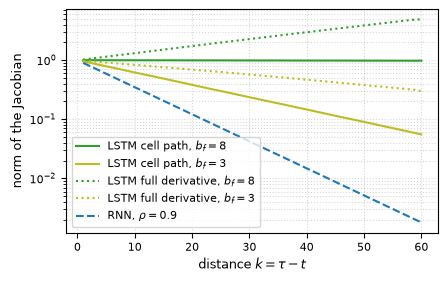

In [7]:
SEED_LSTM_CELL = 3
RESULTS["seeds"]["lstm_cell_path"] = SEED_LSTM_CELL


def lstm_cell_jacobians(forget_bias, detach_h, horizon=HORIZON, n=N_UNITS, seed=SEED_LSTM_CELL, weight_scale=0.1):
    """Run an LSTM cell for `horizon` steps; return d c_K / d c_s for s = 0..K (autograd) and the forget gates.

    With detach_h=True the gates and the candidate see h_{t-1} but no derivative flows through it, which keeps only the
    cell path (12). The forward values are the same either way, so both variants follow one trajectory."""
    gen = torch.Generator().manual_seed(seed)
    W = weight_scale * torch.randn(4 * n, n + N_INPUTS, generator=gen) / math.sqrt(n + N_INPUTS)
    bias = torch.zeros(4 * n)
    bias[:n] = forget_bias
    xs = torch.randn(horizon, N_INPUTS, generator=gen)

    c0 = torch.zeros(n, requires_grad=True)
    c, h = c0, torch.zeros(n)
    cells, forget = [c0], []
    for t in range(horizon):
        h_in = h.detach() if detach_h else h
        z = W @ torch.cat([h_in, xs[t]]) + bias
        f, i, o = torch.sigmoid(z[:n]), torch.sigmoid(z[n:2 * n]), torch.sigmoid(z[2 * n:3 * n])
        c = f * c + i * torch.tanh(z[3 * n:])
        h = o * torch.tanh(c)
        c.retain_grad()
        cells.append(c)
        forget.append(f.detach())

    J_auto = torch.zeros(horizon + 1, n, n)            # J_auto[s] = d c_K / d c_s
    for unit in range(n):
        for cell in cells:
            cell.grad = None
        cells[-1][unit].backward(retain_graph=True)
        for s in range(horizon + 1):
            J_auto[s, unit] = cells[s].grad
    return J_auto, torch.stack(forget)                 # forget[s - 1] = f_s


def lstm_cell_path(forget_bias, horizon=HORIZON):
    """Norms of the cell-path derivative d c_K / d c_{K-k}, k = 1..K: explicit product (12), checked by autograd."""
    J_auto, forget = lstm_cell_jacobians(forget_bias, detach_h=True)
    norms, worst = [], 0.0
    for k in range(1, horizon + 1):
        J_product = torch.diag(forget[horizon - k:].prod(dim=0))
        worst = max(worst, ((J_auto[horizon - k] - J_product).abs().max() / J_product.abs().max()).item())
        norms.append(torch.linalg.matrix_norm(J_product, ord=2).item())
    return norms, worst, forget.mean().item()


def lstm_full_derivative(forget_bias, horizon=HORIZON):
    """Norms of the full derivative d c_K / d c_{K-k}, k = 1..K, with the paths through h into c~_t and the gates."""
    J_auto, _ = lstm_cell_jacobians(forget_bias, detach_h=False)
    return [torch.linalg.matrix_norm(J_auto[horizon - k], ord=2).item() for k in range(1, horizon + 1)]


lstm_cells = {}
for bf in (3.0, 8.0):
    norms, worst, mean_f = lstm_cell_path(bf)
    assert worst <= 1e-12, f"b_f={bf}: autograd differs from the product of diag(f_t) ({worst:.1e})"
    full = lstm_full_derivative(bf)
    assert all(math.isfinite(v) and v > 0 for v in full)
    lstm_cells[f"b_f={bf:g}"] = {"forget_bias": bf, "mean_forget_gate": mean_f,
                                  "factor_per_step": per_step_factor(norms), "norm_k1": norms[0],
                                  "norm_k30": norms[29], "norm_k60": norms[-1], "min_norm": min(norms),
                                  "autograd_max_relative_error": worst, "norms": norms,
                                  "full_factor_per_step": per_step_factor(full), "full_norm_k1": full[0],
                                  "full_norm_k60": full[-1], "full_min_norm": min(full), "full_norms": full}
    print(f"check: b_f = {bf:g}: autograd = ∏ diag(f_t) (rel. error {worst:.1e}); mean f = {mean_f:.4f}, "
          f"factor per step {per_step_factor(norms):.4f}, ‖∂c_60/∂c_0‖ = {norms[-1]:.3f} ✓")
    print(f"       full derivative (paths through h into c~ and the gates kept): factor per step "
          f"{per_step_factor(full):.4f}, ‖∂c_60/∂c_0‖ = {full[-1]:.3f}")

assert lstm_cells["b_f=8"]["min_norm"] > 0.95       # forget gate near one: the cell path keeps the gradient
assert lstm_cells["b_f=3"]["norm_k60"] < 0.2        # the decay rate is set by the forget gate
print(f"check: after 60 steps the cell path keeps {lstm_cells['b_f=8']['norm_k60']:.3f} for b_f = 8 "
      f"and {lstm_cells['b_f=3']['norm_k60']:.3f} for b_f = 3 ✓")

fig, ax = plt.subplots()
ax.semilogy(k_axis, lstm_cells["b_f=8"]["norms"], color="tab:green", label=r"LSTM cell path, $b_f = 8$")
ax.semilogy(k_axis, lstm_cells["b_f=3"]["norms"], color="tab:olive", label=r"LSTM cell path, $b_f = 3$")
ax.semilogy(k_axis, lstm_cells["b_f=8"]["full_norms"], color="tab:green", linestyle=":",
            label=r"LSTM full derivative, $b_f = 8$")
ax.semilogy(k_axis, lstm_cells["b_f=3"]["full_norms"], color="tab:olive", linestyle=":",
            label=r"LSTM full derivative, $b_f = 3$")
ax.semilogy(k_axis, rnn_jacobian["rho=0.9, small inputs"]["norms"], color="tab:blue", linestyle="--",
            label=r"RNN, $\rho = 0.9$")
ax.set_xlabel(r"distance $k = \tau - t$")
ax.set_ylabel("norm of the Jacobian")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="lower left")
save_figure(fig, "lstm_cell_path.pdf")
plt.show()

RESULTS["jacobian"] = {"horizon": HORIZON, "units": N_UNITS, "rnn": rnn_jacobian, "lstm_cell_path": lstm_cells}

## 5. RNN vs LSTM
The experiment of Section 7 of the paper: the variant of the **adding problem** (Hochreiter and Schmidhuber, 1997) used by Arjovsky, Shah and Bengio (2016). Each input sequence has length $T = 50$ and two channels: a value $v_t \sim U(0,1)$ and a marker that equals 1 at exactly two positions, one in each half of the sequence. The target is the sum of the two marked values. Always predicting 1 gives an expected mean squared error of $1/6 \approx 0.167$. Using only the second marked value gives $1/12 \approx 0.083$ (the variance of the first value); to get below that, a model must carry the first value across 25 to 49 steps. Both models have the same width, 64 hidden units, and use the same optimizer (Adam, learning rate $3 \cdot 10^{-3}$, gradient clipping at norm 1), batch size 64, 3000 steps and the same seed, so the comparison measures learning within this budget. Training runs in single precision; the test set is a fixed set of 1000 sequences.

baseline (always 1): test MSE 0.1754
RNN (tanh) test MSE after 3000 steps: 0.1753
LSTM       test MSE after 3000 steps: 0.0001
training time 50.8 s
check: LSTM 0.0001 vs RNN 0.1753 (baseline 0.1754) ✓


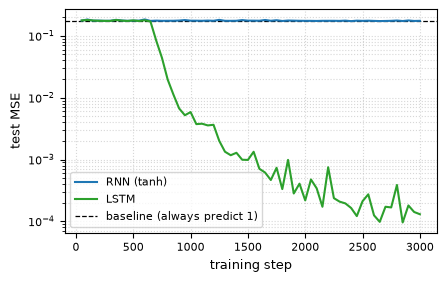

In [8]:
torch.set_default_dtype(torch.float32)
SEQ_LEN, HIDDEN, BATCH, STEPS, LR, EVAL_EVERY, TEST_SIZE = 50, 64, 64, 3000, 3e-3, 50, 1000
SEED_TRAIN, SEED_DATA, SEED_TEST = 0, 1000, 12345
RESULTS["seeds"].update({"training_init": SEED_TRAIN, "training_data": SEED_DATA, "test_set": SEED_TEST})


def adding_batch(n, length, generator):
    """n sequences of the adding problem: inputs (n, length, 2) and targets (n, 1)."""
    values = torch.rand(n, length, generator=generator)
    markers = torch.zeros(n, length)
    rows = torch.arange(n)
    markers[rows, torch.randint(0, length // 2, (n,), generator=generator)] = 1.0
    markers[rows, torch.randint(length // 2, length, (n,), generator=generator)] = 1.0
    return torch.stack([values, markers], dim=-1), (values * markers).sum(dim=1, keepdim=True)


class SequenceRegressor(nn.Module):
    """Recurrent layer (nn.RNN or nn.LSTM) followed by a linear readout of the last state."""

    def __init__(self, recurrent_layer):
        super().__init__()
        self.recurrent = recurrent_layer(input_size=2, hidden_size=HIDDEN, batch_first=True)
        self.readout = nn.Linear(HIDDEN, 1)

    def forward(self, x):
        states, _ = self.recurrent(x)
        return self.readout(states[:, -1])


x_test, y_test = adding_batch(TEST_SIZE, SEQ_LEN, torch.Generator().manual_seed(SEED_TEST))
baseline_mse = ((y_test - 1.0) ** 2).mean().item()


def train(recurrent_layer):
    torch.manual_seed(SEED_TRAIN)
    data = torch.Generator().manual_seed(SEED_DATA)
    model = SequenceRegressor(recurrent_layer)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    curve = []
    for step in range(1, STEPS + 1):
        x_batch, y_batch = adding_batch(BATCH, SEQ_LEN, data)
        loss = ((model(x_batch) - y_batch) ** 2).mean()
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if step % EVAL_EVERY == 0:
            with torch.no_grad():
                curve.append(((model(x_test) - y_test) ** 2).mean().item())
    return curve


t_train = time.perf_counter()
curves = {"RNN (tanh)": train(nn.RNN), "LSTM": train(nn.LSTM)}
train_seconds = time.perf_counter() - t_train
final = {name: curve[-1] for name, curve in curves.items()}
print(f"baseline (always 1): test MSE {baseline_mse:.4f}")
for name, value in final.items():
    print(f"{name:10s} test MSE after {STEPS} steps: {value:.4f}")
print(f"training time {train_seconds:.1f} s")

assert final["LSTM"] < 0.01                         # the LSTM solves the task
assert final["RNN (tanh)"] > 0.5 * baseline_mse     # the plain RNN stays near the baseline
assert final["LSTM"] < final["RNN (tanh)"] / 10
print(f"check: LSTM {final['LSTM']:.4f} vs RNN {final['RNN (tanh)']:.4f} (baseline {baseline_mse:.4f}) ✓")

fig, ax = plt.subplots()
steps_axis = np.arange(EVAL_EVERY, STEPS + 1, EVAL_EVERY)
ax.semilogy(steps_axis, curves["RNN (tanh)"], color="tab:blue", label="RNN (tanh)", zorder=3)
ax.semilogy(steps_axis, curves["LSTM"], color="tab:green", label="LSTM", zorder=3)
ax.axhline(baseline_mse, color="k", linestyle="--", linewidth=0.9, label="baseline (always predict 1)", zorder=2)
ax.set_xlabel("training step")
ax.set_ylabel("test MSE")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="lower left")
save_figure(fig, "rnn_vs_lstm.pdf")
plt.show()

RESULTS["rnn_vs_lstm"] = {
    "task": "adding problem (Hochreiter and Schmidhuber, 1997)", "T": SEQ_LEN, "hidden": HIDDEN,
    "batch": BATCH, "steps": STEPS, "optimizer": f"Adam lr={LR}, gradient-norm clipping 1.0",
    "dtype": "float32", "test_size": TEST_SIZE, "baseline_mse": baseline_mse,
    "final_test_mse": final, "eval_every": EVAL_EVERY, "curves": curves, "training_seconds": train_seconds,
}

In [9]:
RESULTS["figures"] = sorted(p.name for p in FIG_DIR.glob("*.pdf"))
RESULTS["runtime_seconds"] = time.perf_counter() - T_START
with open(PROJECT_DIR / "results.json", "w", encoding="utf-8") as fh:
    json.dump(RESULTS, fh, indent=2, ensure_ascii=False)
print(f"saved results.json and {len(RESULTS['figures'])} figures: {', '.join(RESULTS['figures'])}")
print(f"total runtime {RESULTS['runtime_seconds']:.1f} s")

saved results.json and 4 figures: bptt_contributions.pdf, jacobian_decay.pdf, lstm_cell_path.pdf, rnn_vs_lstm.pdf
total runtime 53.7 s


## 6. Conclusion
- **Worked step (Section 3).** All nine values match Table 1 of the paper, correctly rounded to five decimals, including the gradients $\partial E/\partial W^{(2)} = -0.06423$ and $\partial E/\partial W^{(1)} = -0.01212$. Autograd agrees to $3\cdot 10^{-17}$ and the central difference to $3\cdot 10^{-11}$. One gradient step with $\eta = 1$ lowers the loss from $0.089386$ to $0.085161$.
- **Backpropagation and BPTT.** The recursion (2)–(4) matches autograd on a 4-8-8-3 network to a relative error of $4\cdot 10^{-16}$, and hand-written BPTT matches it exactly. The per-step terms add up to the full gradient; the term from step 2 is $9\cdot 10^{-5}$ against $1.9$ from step 20.
- **Vanishing and exploding gradients.** The Jacobian product shrinks by a factor of $0.900$ per step for $\rho = 0.9$ and grows by $1.100$ for $\rho = 1.1$, as $\rho^k$ predicts. Saturated tanh units turn the growth into decay (factor $0.475$ in this random draw), although the bound (10), which uses only the largest entry of each factor, evaluates to $100$ at $k = 60$ along that trajectory.
- **LSTM.** Along the cell path the factor per step is the forget gate itself: $0.953$ for $b_f = 3$ and $0.9997$ for $b_f = 8$. After 60 steps the cell path keeps $0.980$ of the gradient for $b_f = 8$. Unlike the RNN path, it contains no derivative of a saturating function. The full derivative, which also runs through $h$ into $\tilde c_t$ and the gates, changes by a factor of $1.027$ per step for $b_f = 8$ and $0.980$ for $b_f = 3$.
- **Adding problem, $T = 50$.** Within 3000 steps the plain RNN stays at the baseline (test MSE $0.1753$ against $0.1754$ for always predicting 1), while the LSTM of the same width reaches $0.0001$ in this run. The comparison measures learning within this budget; it does not show whether the plain RNN learns with more steps, and it does not measure the cell path.